# RDataFrameDSL Phase 13.6.F - Draw API Examples

Interactive notebook for exploring the DSL → Draw workflow.

**Features demonstrated:**
- `alias()` - Deferred validation (TTree::SetAlias style)
- `from_rdf()` - Schema inference from RDataFrame
- `draw()` - Single plot with Layer 1 validation
- `batch_draw()` - Multiple plots efficiently
- `to_pandas_safe()` - Protected export with probe-run

In [1]:
# Setup - Add parent directory to path for imports
import sys
import os

# Get the RDataFrameDSL root directory (parent of examples/)
notebook_dir = os.path.dirname(os.path.abspath('.'))
if 'examples' in os.getcwd():
    rdsl_root = os.path.dirname(os.getcwd())
else:
    rdsl_root = os.getcwd()

if rdsl_root not in sys.path:
    sys.path.insert(0, rdsl_root)

print(f"Added to path: {rdsl_root}")

# Now import
import ROOT
import numpy as np
import pandas as pd

from RDataFrameDSL import DSLCompiler
from RDataFrameDSL.ir_errors import IRError

print(f"ROOT version: {ROOT.gROOT.GetVersion()}")
print(f"Python version: {sys.version}")

Added to path: /Users/miranov25/alicesw/O2DPG/UTILS/dfextensions/RDataFrameDSL
ROOT version: 6.32.06
Python version: 3.9.6 (default, Feb  3 2024, 15:58:27) 
[Clang 15.0.0 (clang-1500.3.9.4)]


## Create Test Data

Generate RDataFrame with track-like data for testing.

In [2]:
def create_test_data(n_events=1000):
    """Create test RDataFrame with track-like data."""
    rdf = ROOT.RDataFrame(n_events)
    
    # Event-level columns
    rdf = rdf.Define("event_id", "rdfentry_")
    rdf = rdf.Define("n_tracks", "gRandom->Poisson(5)")
    rdf = rdf.Define("event_weight", "gRandom->Gaus(1.0, 0.1)")
    
    # Track-level columns (1D arrays)
    rdf = rdf.Define("track_pt", 
        "ROOT::RVecD v(n_tracks); for(auto& x:v) x=gRandom->Exp(2.0); return v;")
    rdf = rdf.Define("track_eta",
        "ROOT::RVecD v(n_tracks); for(auto& x:v) x=gRandom->Gaus(0,1.0); return v;")
    rdf = rdf.Define("track_phi",
        "ROOT::RVecD v(n_tracks); for(auto& x:v) x=gRandom->Uniform(-3.14159,3.14159); return v;")
    
    return rdf

# Create data
rdf = create_test_data(1000)
print(f"Created RDataFrame with columns: {[str(c) for c in rdf.GetColumnNames()]}")

Created RDataFrame with columns: ['event_id', 'event_weight', 'n_tracks', 'track_eta', 'track_phi', 'track_pt']


## Example 1: from_rdf() and Schema Inference

In [3]:
# Create DSLCompiler with schema inferred from RDataFrame
dsl = DSLCompiler.from_rdf(rdf)

print("Inferred schema:")
for name, dtype in dsl.schema.items():
    print(f"  {name}: {dtype}")

Inferred schema:
  event_id: ULong64_t
  event_weight: double
  n_tracks: ULong64_t
  track_eta: ROOT::VecOps::RVec<double>
  track_phi: ROOT::VecOps::RVec<double>
  track_pt: ROOT::VecOps::RVec<double>


## Example 2: alias() - Deferred Validation

In [4]:
# Define aliases - NOT validated until used
dsl.alias("pt_scaled", "track_pt * 1000")  # MeV
dsl.alias("high_pt", "track_pt > 2.0")
dsl.alias("central", "abs(track_eta) < 1.0")

print("Aliases in pool (not yet compiled):")
print(f"  {list(dsl._aliases.keys())}")

print("\nSchema (aliases not yet added):")
print(f"  {list(dsl.schema.keys())}")

Aliases in pool (not yet compiled):
  ['pt_scaled', 'high_pt', 'central']

Schema (aliases not yet added):
  ['event_id', 'event_weight', 'n_tracks', 'track_eta', 'track_phi', 'track_pt']


## Example 3: to_pandas() with Alias Materialization

In [5]:
# Export to pandas - this materializes needed aliases
df = dsl.to_pandas(rdf, columns=['event_id', 'track_pt', 'pt_scaled', 'high_pt'])

print(f"Exported {len(df)} rows")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 10 rows:")
df.head(10)

Exported 5001 rows

Columns: ['event_id', 'track_idx', 'track_pt', 'pt_scaled', 'high_pt']

First 10 rows:


,event_id,track_idx,track_pt,pt_scaled,high_pt
0,0,0,0.086907,86.907249,False
1,0,1,0.590608,590.607842,False
2,0,2,1.232211,1232.210588,False
3,0,3,0.602337,602.337267,False
4,0,4,0.549022,549.021596,False
5,1,0,3.013152,3013.151846,True
6,1,1,3.091139,3091.138679,True
7,1,2,6.990893,6990.892772,True
8,1,3,2.195989,2195.989460,True
9,1,4,3.278260,3278.260286,True


In [6]:
# Verify alias computation
print("Verification: pt_scaled == track_pt * 1000")
np.testing.assert_array_almost_equal(
    df['pt_scaled'].values,
    df['track_pt'].values * 1000
)
print("✓ Verified!")

print(f"\nAlias pool after materialization: {list(dsl._aliases.keys())}")
print(f"Schema after materialization: {list(dsl.schema.keys())}")

Verification: pt_scaled == track_pt * 1000
✓ Verified!

Alias pool after materialization: ['central']
Schema after materialization: ['event_id', 'event_weight', 'n_tracks', 'track_eta', 'track_phi', 'track_pt', 'pt_scaled', 'high_pt']


## Example 4: draw() - Single Plot

Stats: {'n': 4909, 'mean': 2.0245277056417876, 'std': 2.0269130011289076, 'min': 0.0001963519947140506, 'max': 25.131676133987987}


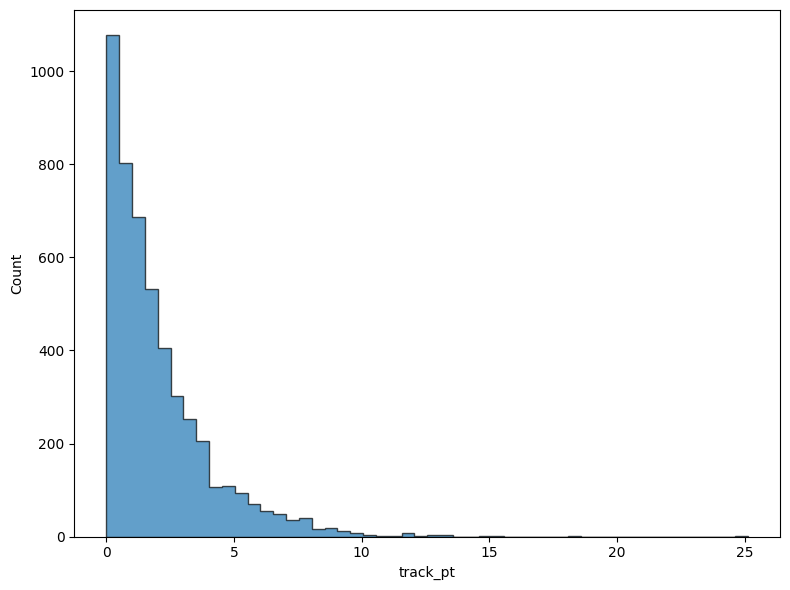

In [7]:
# Fresh DSL for draw example
dsl2 = DSLCompiler.from_rdf(rdf)

try:
    fig, ax, stats = dsl2.draw("track_pt", rdf, bins=50)
    print(f"Stats: {stats}")
except ImportError as e:
    print(f"dfdraw not installed: {e}")
    print("Install with: pip install dfdraw")

## Example 5: Layer 1 Validation

In [8]:
# Layer 1 catches errors BEFORE ROOT execution
dsl3 = DSLCompiler.from_rdf(rdf)

try:
    dsl3.draw("nonexistent_column", rdf)
except IRError as e:
    print(f"✓ IRError caught (not ROOT crash):")
    print(f"  {e}")
    print(f"\n  Suggestions: {e.suggestions}")

✓ IRError caught (not ROOT crash):
  IRError(type): Column not found: nonexistent_column
  Suggestions:
    • 'nonexistent_column' - no similar names found
    • Available columns: event_id, event_weight, n_tracks, track_eta, track_phi, track_pt

  Suggestions: ["'nonexistent_column' - no similar names found", 'Available columns: event_id, event_weight, n_tracks, track_eta, track_phi, track_pt']


/Users/miranov25/alicesw/O2DPG/UTILS/dfextensions/RDataFrameDSL/RDataFrameDSL/dsl_compiler.py:2056: UserWarning: Columns not in schema (will try as raw branches): {'nonexistent_column'}
Known columns: ['event_id', 'event_weight', 'n_tracks', 'track_eta', 'track_phi', 'track_pt']
  warnings.warn(


## Example 6: batch_draw() - Multiple Plots

Created 3 plots:
  - pt_dist
  - eta_dist
  - phi_dist


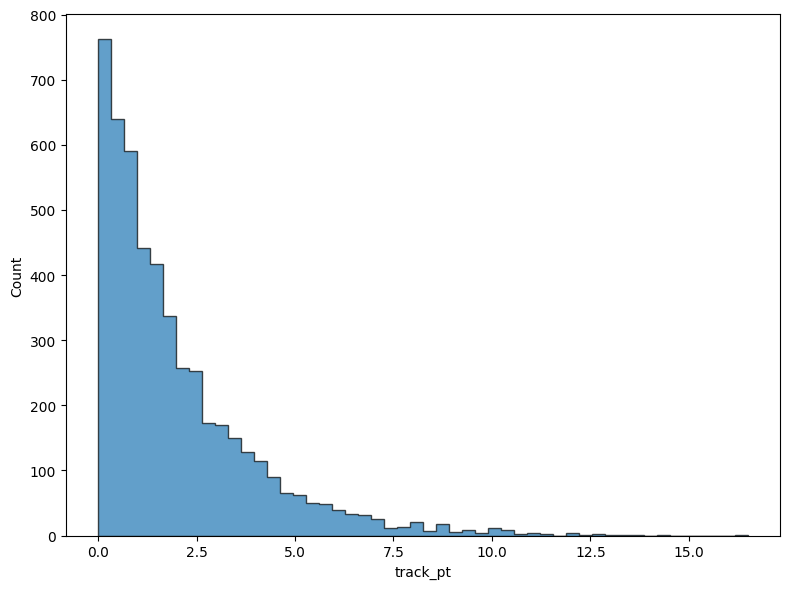

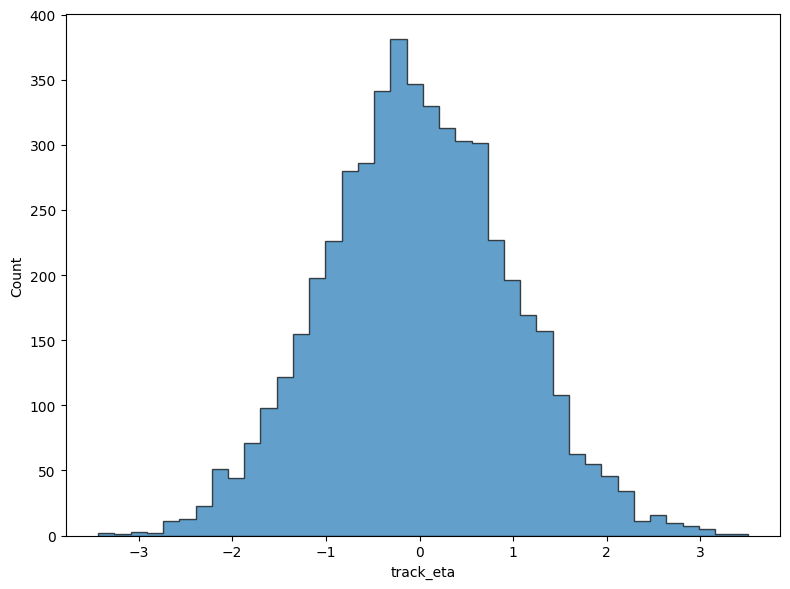

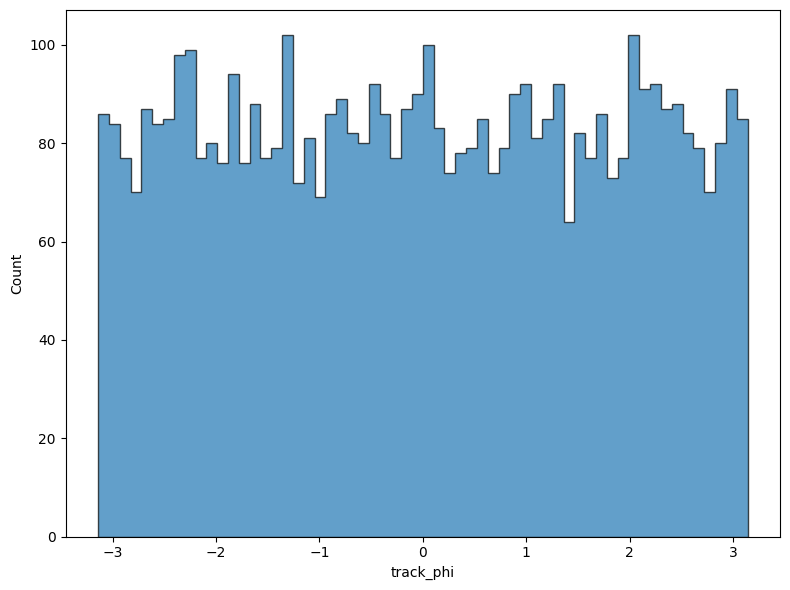

In [9]:
dsl4 = DSLCompiler.from_rdf(rdf)

specs = {
    'pt_dist': {'expr': 'track_pt', 'bins': 50},
    'eta_dist': {'expr': 'track_eta', 'bins': 40},
    'phi_dist': {'expr': 'track_phi', 'bins': 60},
}

try:
    results = dsl4.draw_batch(specs, rdf)
    print(f"Created {len(results)} plots:")
    for name in results:
        print(f"  - {name}")
except ImportError as e:
    print(f"dfdraw not installed: {e}")

## Example 7: to_pandas_safe() - Protected Export

In [10]:
import sys

if sys.platform == "win32":
    print("Safe mode requires fork() - not available on Windows")
else:
    dsl5 = DSLCompiler.from_rdf(rdf)
    
    # Safe export with probe-run protection
    df_safe = dsl5.to_pandas_safe(
        rdf,
        columns=['event_id', 'track_pt'],
        probe_size=100  # Test on 100 entries first
    )
    
    print(f"✓ Safe export: {len(df_safe)} rows")
    df_safe.head()

✓ Safe export: 5059 rows


## Example 8: Alias Chain Compilation

In [11]:
results

{'pt_dist': {'fig': <Figure size 800x600 with 1 Axes>,
  'ax': <Axes: xlabel='track_pt', ylabel='Count'>,
  'stats': {'n': 5008,
   'mean': 1.9856336793308986,
   'std': 1.9873203359713218,
   'min': 0.00020159679389612425,
   'max': 16.492620259070147}},
 'eta_dist': {'fig': <Figure size 800x600 with 1 Axes>,
  'ax': <Axes: xlabel='track_eta', ylabel='Count'>,
  'stats': {'n': 5008,
   'mean': -0.01921835387458335,
   'std': 0.9866953869363335,
   'min': -3.4319916434195887,
   'max': 3.50301277982284}},
 'phi_dist': {'fig': <Figure size 800x600 with 1 Axes>,
  'ax': <Axes: xlabel='track_phi', ylabel='Count'>,
  'stats': {'n': 5008,
   'mean': -0.0003975629737297504,
   'std': 1.8140963188602386,
   'min': -3.1405901972786663,
   'max': 3.1413535736201563}}}

In [12]:
dsl6 = DSLCompiler.from_rdf(rdf)

# Define chain: c depends on b, b depends on a
dsl6.alias("a", "event_weight")
dsl6.alias("b", "a + 1")
dsl6.alias("c", "b + 1")

# Also some unused aliases
dsl6.alias("unused", "track_phi * 2")

print(f"Pool before: {list(dsl6._aliases.keys())}")

# Request only 'c' - should compile a, b, c but NOT unused
df_chain = dsl6.to_pandas(rdf, columns=['event_weight', 'c'])

print(f"Pool after: {list(dsl6._aliases.keys())}")
print(f"\nVerify: c = event_weight + 2")
np.testing.assert_array_almost_equal(
    df_chain['c'].values,
    df_chain['event_weight'].values + 2
)
print("✓ Verified!")

Pool before: ['a', 'b', 'c', 'unused']
Pool after: ['unused']

Verify: c = event_weight + 2
✓ Verified!


## Exploration Area

Use this cell to experiment with the DSL:

In [13]:
# Your experiments here
dsl_exp = DSLCompiler.from_rdf(rdf)

# Example: Try your own expressions
# dsl_exp.alias("my_alias", "...")
# df = dsl_exp.to_pandas(rdf, columns=[...])